In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [41]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,classification_report)
from sklearn.svm import SVC

In [42]:
print("Downloading Fashion MNIST dataset");

X,y=fetch_openml('Fashion-MNIST',version=1,return_X_y=True,as_frame=False)
X=X.astype('float32')
y=y.astype('int')

print("Dataset Shape",X.shape)
X=X[:10000]
y=y[:10000]



Dataset Shape (70000, 784)


In [43]:
x_train,x_test,y_train,y_test=train_test_split(X,y,
    test_size=0.2,random_state=42,stratify=y
)

print("Training Sample",x_train.shape[0])
print("Testing Sample",x_test.shape[0])

Training Sample 8000
Testing Sample 2000


In [44]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [45]:
print("nTraining Linear SVM...")
linear_svm=SVC(kernel='linear')
linear_svm.fit(x_train,y_train)

y_pred_linear=linear_svm.predict(x_test)
linear_accuracy=accuracy_score(y_test,y_pred_linear)
print("Linear SVM Accuracy",linear_accuracy*100,"%")

nTraining Linear SVM...
Linear SVM Accuracy 80.75 %


In [46]:
print("\n Training RBF SVM...")

rbf_svm=SVC(kernel='rbf',gamma='scale')

rbf_svm.fit(x_train,y_train)
y_pred_rbf=rbf_svm.predict(x_test)
rbf_accuracy=accuracy_score(y_test,y_pred_rbf)
print("RBF SVM Accuracy:",rbf_accuracy*100,"%")


 Training RBF SVM...
RBF SVM Accuracy: 85.25 %


In [47]:
print("\n---Lineae SVM Classification Report----")
print(classification_report(y_test,y_pred_linear))
print("\n---RBF SVM Classification REport ---")
print(classification_report(y_test,y_pred_rbf))


---Lineae SVM Classification Report----
              precision    recall  f1-score   support

           0       0.68      0.83      0.74       189
           1       0.95      0.97      0.96       205
           2       0.64      0.71      0.67       203
           3       0.83      0.79      0.81       204
           4       0.65      0.62      0.63       195
           5       0.91      0.92      0.91       198
           6       0.63      0.50      0.55       204
           7       0.89      0.89      0.89       204
           8       0.97      0.95      0.96       198
           9       0.92      0.92      0.92       200

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000


---RBF SVM Classification REport ---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       189
           1       1.00      0.96      0.98       205

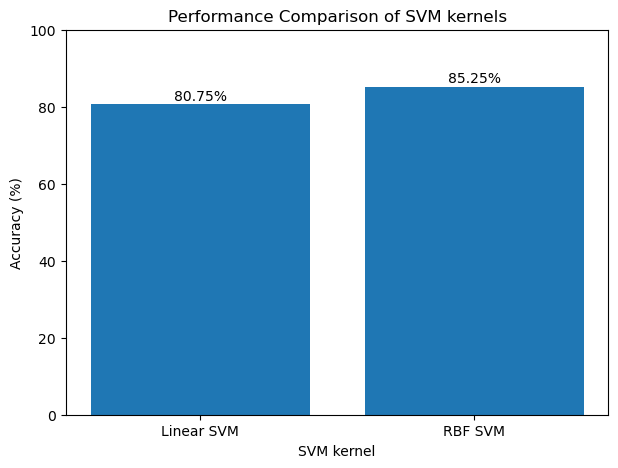

In [49]:
models=['Linear SVM','RBF SVM']
accuracy=[linear_accuracy*100,rbf_accuracy*100]

plt.figure(figsize=(7,5))
bars=plt.bar(models,accuracy)
plt.ylabel("Accuracy (%)")
plt.xlabel("SVM kernel")
plt.title("Performance Comparison of SVM kernels")


plt.ylim(0,100)

for bar,value in zip(bars,accuracy):
    plt.text(
        bar.get_x()+ bar.get_width()/2,
        value +1,
        f"{value:.2f}%",ha='center'
    )
plt.show()